# Chapter 31. GRPO — 검증 가능한 보상으로 정렬 (Group Relative Policy Optimization, Phase 4 마지막)

**목표**: Phase 4 의 *마지막 챕터*. Ch 30 에서 **DPO** 로 *사람/AI 가 비교한 preference 쌍 (chosen / rejected)* 으로 정렬했다면, 본 챕터는 alignment 의 *두 번째 방식* — **GRPO (Group Relative Policy Optimization)** 입니다. GRPO 는 정반대 접근으로, *정답을 자동 검증(verifier) 할 수 있는 task (수학·코드)* 에서 모델이 *여러 답을 생성(rollout)* 하고 *verifier 가 채점* 해 *잘한 답 방향* 으로 강화학습 합니다. **DeepSeek-R1 이 순수 RL 로 reasoning 능력을 끌어낸 방법** 이 바로 이것입니다. 바뀌는 건 **신호 출처 (preference 쌍 → verifier reward)** + **trainer (`DPOTrainer` → `trl.GRPOTrainer`)** + **데이터 (chosen/rejected → prompt + 정답)** + **rollout (한 prompt 에 여러 답 생성)** 입니다.

**환경**: Google Colab **T4 GPU 필수**. GRPO 는 *매 step 여러 답을 생성(rollout)* 하므로 무겁습니다 — group size 를 작게 (8) + 짧은 generation + 작은 step 으로 시간을 통제합니다.

**예상 소요 시간**: 약 4-6분 (환경 셋업·데이터 약 1분 + **SFT 워밍스타트 약 1분** + **난이도 필터 약 1분** + `GRPOTrainer` 학습 약 1분 + GRPO 전·후 정확도 비교 약 1분). GRPO 자체는 짧지만, *rollout 이 무거운* 실제 학습은 step·group 을 키우면 그만큼 늘어납니다.

---

## 학습 흐름

1. 📊 **누적 추적표** (Ch 28/29/30 + **31 강조**) + GPT 학습 4단계 표 (Ch 30 DPO·Ch 31 GRPO = 단계 4 alignment 의 두 방식)
2. 🔄 **변경점 (Diff from Ch 30 DPO)** — *신호 출처 + trainer + 데이터 + rollout* 이 변함
3. 🎯 **PPO vs DPO vs GRPO 대비 표** — 신호·모델·데이터. *왜 GRPO 가 critic 도 reward model 도 없이 되나*
4. 📐 **GRPO 메커니즘** — rollout group → verifier reward → group relative advantage 수식 + 수치 예시
5. 🔬 **verifiable reward 의 의미** — 정답 있는 task 는 사람 채점 없이 무한 RL 신호. DeepSeek-R1 의 reasoning
6. 🔤 **토크나이저 노트** — KoGPT2 `PreTrainedTokenizerFast` (Ch 27 이후 고정)
7. 🚀 **실습**: verifiable 데이터(train/eval 분리) → **SFT 워밍스타트** → verifier·group advantage 손계산 → **난이도 필터** → `GRPOTrainer` 학습 → GRPO 전·후 정확도 비교
8. 🔍 **왜 reward 가 잘 안 올랐는가** — GRPO 의 전제조건 (SFT 워밍스타트·난이도 필터가 왜 필요한지)
9. 📦 **등장 라이브러리** (`trl.GRPOTrainer`·`GRPOConfig`·`reward_funcs` 첫 등장) / 🎯 **체크포인트** / ❓ **FAQ** (답변 포함)
10. 🎓 **Phase 4 회고 + Phase 5 (Diffusion LM) 예고**

---

> 📒 **사전 학습 자료**: Ch 30 (DPO — alignment 의 첫 방식), Ch 28 (KoGPT2 SFT — 본 챕터의 *출발 모델*), Ch 29 (벤치마크 평가 — 특히 부록의 *pass@1·cons@64* 가 verifiable reward 와 직접 연결). 본 챕터는 *alignment 의 두 방식 비교* 를 완성합니다: **DPO (주관적 선호, 사람/AI 비교) vs GRPO (객관적 정답, 자동 검증)**.

## 📊 누적 추적표

| Ch | 모델 | 데이터 | 학습 신호 | Loss | Trainer |
|---|---|---|---|---|---|
| 28 | KoGPT2 (125M, SFT) | KoAlpaca instruction-response 쌍 | response 토큰 (답변만) | `CrossEntropyLoss` (response-only) - SFT | `SFTTrainer` |
| 29 | Qwen2.5-0.5B-Instruct (+ Ch 28 SFT 모델 대조) | KoBEST/산술 subset | - (평가만) | - (`lm-evaluation-harness`) | - |
| 30 | SFT 모델 (policy) + frozen reference | preference 쌍 (chosen / rejected) | chosen 선호 ↑ / rejected 선호 ↓ | DPO sigmoid loss (β=0.1) | `DPOTrainer` |
| **31 ← 여기** | **SFT 모델 (policy) + verifier** | **prompt + 정답 (검증 가능, 수학)** | **group relative advantage** | **GRPO loss (group baseline)** | **`GRPOTrainer`** |

전체 챕터 표는 [루트 README](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표) 를 참고하세요.

---

## 🌏 GPT 시대 학습 4단계 — 본 챕터의 위치 (단계 4, Alignment 의 두 번째 방식 / GRPO)

Ch 24 에서 도입한 GPT 시대 학습 4단계 표. 본 챕터는 *단계 4 (Alignment)* 의 *두 번째 방식* — Ch 30 DPO 와 Ch 31 GRPO 가 *alignment 의 두 방식* 입니다.

| 단계 | 정확 용어 | 의미 | 학습 신호 | 본 커리큘럼 | 본 챕터? |
|---|---|---|---|---|---|
| 1 | **Pretraining** (사전학습) | random init 본체 + 일반 코퍼스 | next-token | Ch 24 (영어), Ch 26 (한국어) | |
| 2 | **Continual pretraining** (계속 사전학습) | 사전학습 본체 + 새 데이터 | next-token | Ch 25 (영어), Ch 27 (한국어) | |
| 3 | **SFT** (Supervised Fine-Tuning) | instruction-response 로 *행동 정렬* | response 토큰 | Ch 28 | |
| 4 | **Alignment** (DPO / GRPO / RLHF) | preference·verifier reward 로 *선호·능력 정렬* | preference 쌍 / reward | Ch 30 (DPO), **Ch 31 (GRPO) ← 여기** | ✅ |

### alignment 의 두 방식 — DPO vs GRPO

- **DPO (Ch 30)**: *"같은 질문에 좋은 답 vs 나쁜 답"* preference 쌍으로 학습. 신호는 *사람/AI 가 비교* 한 *주관적 선호*. 열린 질문(글쓰기·대화·취향) 처럼 *정답이 없는* task 에 적합
- **GRPO (Ch 31, 본 챕터)**: *"이 답이 맞나"* 를 *자동 검증(verifier)* 해 reward. 신호는 *객관적 정답* (수학 답이 맞나, 코드가 테스트를 통과하나). *정답을 자동 확인할 수 있는* task 에 적합

> DPO 가 *사람의 선호* 를 따라간다면, GRPO 는 *정답이라는 객관 신호* 를 따라갑니다. 후자의 강점은 ***사람 채점 없이 무한히 RL 신호를 만들 수 있다*** 는 것 — 정답이 있는 task 라면 verifier 가 *공짜 reward model* 역할을 합니다. DeepSeek-R1 이 이걸로 *순수 RL 만으로 reasoning* 능력을 끌어냈습니다 (§6).

## 🔄 변경점 (Diff from Ch 30 DPO)

| 축 | Ch 30 (DPO) | Ch 31 (본 챕터, GRPO) |
|---|---|---|
| 본체 | SFT 모델 (policy) + frozen reference | **SFT 모델 (policy)** ← *reference 는 옵션* (β=0 이면 불필요) |
| 토크나이저 | `PreTrainedTokenizerFast` (KoGPT2 BBPE) | **(동일)** ← 고정 |
| **신호 출처** | preference 쌍 (사람/AI 가 비교) | **verifier reward (정답 자동 검증)** ← *변화 1* |
| **Trainer** | `trl.DPOTrainer` | **`trl.GRPOTrainer`** ← *변화 2* (새 클래스, 첫 등장) |
| **데이터** | `(prompt, chosen, rejected)` 쌍 | **`(prompt, 정답)`** ← *변화 3* (검증 가능한 task) |
| **rollout** | 없음 (주어진 쌍을 비교) | **한 prompt 에 여러 답 생성** ← *변화 4* (group rollout) |
| **Loss** | DPO sigmoid loss | **GRPO loss (group relative advantage)** ← *변화 5* |
| advantage baseline | - (쌍 비교) | **group 평균** (critic 대신) |

> **핵심**: DPO 는 *주어진 (좋은 답, 나쁜 답) 쌍* 을 *비교* 했다면, GRPO 는 *모델이 직접 여러 답을 생성* 하고 *verifier 가 채점* 해 *그룹 안에서 상대 비교* 합니다. 가장 큰 변화는 *신호의 출처* — *사람/AI 가 만든 preference* 에서 *정답 자동 검증* 으로. 그래서 *정답이 있는 task (수학·코드)* 라면 *사람 없이 무한히 RL 신호* 를 만들 수 있습니다.

## 🎯 PPO vs DPO vs GRPO — alignment 의 세 갈래 (본 챕터의 뼈대)

alignment 의 세 방법을 *신호 출처·필요 모델·데이터* 로 정리합니다. GRPO 의 위치를 이 표 하나로 잡습니다.

| 방법 | 신호 출처 | 필요 모델 | 데이터 | T4 |
|---|---|---|---|---|
| **PPO** (전통 RLHF) | reward model 점수 | actor + critic + reward model + reference (**4개**) | prompt + 학습된 RM | ✗ (메모리 초과) |
| **DPO** (Ch 30) | preference 쌍 (사람/AI 비교) | policy + frozen reference (**2개**) | `(prompt, chosen, rejected)` | ✓ |
| **GRPO** (Ch 31, 본 챕터) | **verifier (정답 자동 검증)** | **policy** (+ reference; β>0 이면 필수) | **`(prompt, 정답)` — 검증 가능** | ✓ |

### 왜 GRPO 는 critic 도 reward model 도 없이 되나 — *group 평균이 baseline*

전통 PPO 는 *advantage* 를 계산하려고 **critic (value model)** 을 따로 둡니다 — "이 상태에서 기대되는 reward 가 얼마인가" 의 *baseline* 을 추정하기 위해서입니다. advantage = (실제 reward) − (critic 이 예측한 baseline).

GRPO 의 통찰: **같은 prompt 에 답을 여러 개 (group) 생성하면, *그 group 의 평균 reward* 가 곧 baseline 이 된다.** critic 을 학습할 필요가 없습니다 — *그룹 동료들의 평균* 이 "이 prompt 에서 보통 어느 정도 받나" 를 알려주니까요.

| 항목 | PPO | GRPO |
|---|---|---|
| baseline (advantage 기준) | **critic (value model)** 이 예측 | **group 평균 reward** (동료 비교) |
| reward 출처 | **reward model** (별도 학습) | **verifier** (정답 자동 검증, 학습 불필요) |
| 필요 모델 | actor + critic + RM + ref (4) | **policy** (+ reference; 본 노트북은 β=0.04 라 2개) |

> **GRPO 는 PPO 의 또 다른 간소화** 입니다. DPO 가 *reward model + RL 루프* 를 *지도학습 한 단계* 로 줄였다면, GRPO 는 *critic 을 group 평균* 으로, *reward model 을 verifier* 로 대체합니다. 둘 다 *PPO 의 4 모델* 을 덜어내는 길이지만, GRPO 는 *RL 루프(rollout)는 유지* 하면서 *critic 과 RM 만* 없앤 점이 다릅니다 — 그래서 *정답이 있는 task* 에서 강력합니다.

## 📐 GRPO 메커니즘 — rollout group → verifier reward → group relative advantage

GRPO 의 한 step 은 네 단계입니다:

1. **rollout**: 한 prompt $x$ 에 대해 policy 가 **여러 답 (group)** $\{y_1, \dots, y_G\}$ 을 생성 (예: $G=4$)
2. **verifier reward**: 각 답을 verifier 로 채점 → reward $\{r_1, \dots, r_G\}$ (수학: 정답이면 1, 아니면 0)
3. **group relative advantage**: group 내에서 *평균 대비 상대 위치* 로 advantage 를 계산:

$$A_i = \frac{r_i - \text{mean}(r_1, \dots, r_G)}{\text{std}(r_1, \dots, r_G) + \varepsilon}$$

4. **정책 갱신**: advantage 가 *양수* 인 답 (group 평균보다 잘함) 의 확률은 ↑, *음수* 인 답은 ↓

여기서 **group 평균이 baseline** 역할을 합니다 — "이 prompt 에서 동료들은 평균 얼마나 받았나" 보다 *잘했으면* advantage 양수. 그래서 *critic (value model) 이 불필요* 합니다 (위 §의 PPO 대비 핵심 간소화).

### 수치 예시 — group 4개 답, reward → advantage

한 prompt 에 4개 답을 생성하고 verifier 로 채점한 reward 가 $[1, 0, 1, 0]$ 라고 합시다 (2개 정답, 2개 오답):

| 답 | reward $r_i$ | $r_i - \text{mean}$ | advantage $A_i = (r_i - \text{mean}) / \text{std}$ | 정책 갱신 |
|---|---|---|---|---|
| $y_1$ | 1 | +0.5 | **+0.87** | 확률 ↑ (잘함) |
| $y_2$ | 0 | −0.5 | **−0.87** | 확률 ↓ (못함) |
| $y_3$ | 1 | +0.5 | **+0.87** | 확률 ↑ (잘함) |
| $y_4$ | 0 | −0.5 | **−0.87** | 확률 ↓ (못함) |

(mean = 0.5, 표본std ≈ 0.58) → 정답인 답은 *advantage ≈ +0.87* 로 강화, 오답은 *≈ −0.87* 로 억제. **reward 자체가 아니라 *그룹 평균 대비 상대값* 으로 학습** 한다는 점이 핵심입니다. (std 는 *표본표준편차 ddof=1* — trl 이 쓰는 값과 같게 맞췄습니다.)

다른 group $[1, 1, 1, 0]$ (3개 정답, 1개 오답) 이라면: mean=0.75, 표본std=0.5 → 정답 advantage = **+0.5**, 오답 = **−1.5**. *동료 대부분이 맞힌 상황에서 혼자 틀린 답* 이 더 크게 억제됩니다.

### 모든 답이 같으면 — 학습 신호 0

group 전체가 정답 $[1,1,1,1]$ 이거나 전체 오답 $[0,0,0,0]$ 이면 std = 0 → **advantage 가 전부 0** → 그 prompt 에서는 학습 신호가 없습니다. *그룹 안에 잘한 답과 못한 답이 섞여 있어야* 비교가 생깁니다. (그래서 group size 와 temperature 로 *답의 다양성* 을 확보하는 게 중요 — §의 변형.)

> **§3 에서 실제 verifier 와 group advantage 를 손으로 계산** 해 위 표를 재현합니다. `GRPOTrainer` 가 매 step·매 prompt 내부에서 하는 일이 정확히 이것입니다 — 본 노트북은 `scale_rewards="group"`(std 정규화) + 표본std(ddof=1) 라 위 수식·수치가 trainer 내부 계산과 그대로 일치합니다.

## 🔬 verifiable reward 의 의미 — 정답 있는 task 는 무한 RL 신호

GRPO 의 진짜 힘은 *알고리즘* 보다 **reward 의 출처** 에 있습니다.

### verifiable reward = *자동 채점 가능한* 신호

- **DPO 의 신호**: *사람/AI 가 비교* 한 preference 쌍. 만들려면 *사람 라벨링* 이나 *강한 judge 모델 (GPT-4)* 이 필요 → *비용·확장 한계*
- **GRPO 의 신호 (verifiable)**: *정답을 자동 검증* (수학 답 일치, 코드 테스트 통과). 한 번 verifier 를 만들면 *사람 없이 무한히* reward 를 생성 → *확장 자유*

| | DPO (preference) | GRPO (verifiable reward) |
|---|---|---|
| reward 만드는 주체 | 사람 / judge 모델 | **verifier (규칙·테스트)** |
| 비용 | 라벨당 비용 (사람·API) | **거의 0** (검증은 자동) |
| 확장성 | 라벨 수에 묶임 | **정답만 있으면 무한 rollout** |
| 적용 범위 | 모든 task (주관 포함) | **검증 가능한 task 만** (수학·코드·형식) |

### DeepSeek-R1 — 순수 RL 로 reasoning

DeepSeek-R1 (그리고 R1-Zero) 은 *수학·코드처럼 정답을 자동 검증* 할 수 있는 문제에 GRPO 를 대규모로 적용해, **사람의 reasoning 데모(SFT) 없이도 모델이 스스로 *긴 사고 과정(chain-of-thought)* 을 만들어내게** 했습니다. 정답이라는 *객관 신호* 만으로, 모델이 *"천천히 단계를 밟아 풀면 정답률이 오른다"* 를 *스스로 발견* 한 것입니다.

> Ch 29 부록에서 본 **pass@1 vs cons@64** (한 번 맞히기 vs 여러 번 생성해 다수결) 가 여기 직접 연결됩니다. verifiable task 는 *여러 답을 생성해 정답을 골라낼 수 있으니*, GRPO 의 *group rollout + verifier* 와 자연스럽게 맞물립니다. *생성을 여러 번 해 정답을 확인* 하는 평가(cons@64)가, *생성을 여러 번 해 정답 방향으로 학습* 하는 GRPO 와 같은 뿌리입니다.

### 한계 — 검증 가능한 task 에만

verifiable reward 의 강점은 *검증 가능한 task* 에서만 성립합니다:

- ✅ **잘 맞음**: 수학 (답 일치), 코드 (테스트 통과), 형식 준수 (정규식·파서), 게임 (승패)
- ✗ **안 맞음**: 글쓰기·대화·요약·취향 — *"무엇이 정답인지" 자동 판정이 어려움*. 이런 *열린 질문* 은 DPO (사람 선호) 나 *LLM-as-judge* (Ch 29 부록) 가 적합

> 실무에서는 **두 신호를 섞습니다** — *검증 가능한 부분은 verifier (GRPO)*, *주관적 품질은 preference/judge (DPO)*. 본 챕터는 *verifiable reward 의 원리* 를 *산술 task* 로 가장 깨끗하게 보입니다.

## 🔤 토크나이저 노트 — KoGPT2 `PreTrainedTokenizerFast` (Ch 27 이후 고정)

본 챕터의 토크나이저는 *Ch 27·28·30 과 완전히 동일*. KoGPT2 BBPE (vocab 51,200) 를 그대로 가져옵니다. **KoGPT2 는 `AutoTokenizer` 가 영어 GPT2 로 잘못 fallback 하는 함정** 이 있어 (Ch 27 §토크나이저 노트), `PreTrainedTokenizerFast` + special token 명시로 로드합니다.

```python
from transformers import PreTrainedTokenizerFast
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    bos_token="</s>", eos_token="</s>", unk_token="<unk>",
    pad_token="<pad>", mask_token="<mask>",
)
```

### GRPO 데이터의 토큰화 — prompt 만 입력, 답은 *생성*

DPO 데이터는 `(prompt, chosen, rejected)` *세 텍스트* 였습니다. **GRPO 데이터는 `prompt` 하나만** 토큰화해 모델에 넣고, *답(completion)은 모델이 직접 생성(rollout)* 합니다. 정답은 *토큰화 대상이 아니라 verifier 가 채점할 때만* 쓰는 *추가 컬럼* 입니다.

1. `prompt` 를 토큰화 → policy 에 입력
2. policy 가 `num_generations` 개의 *completion 을 생성* (rollout) — 각 completion 도 KoGPT2 토크나이저로 디코딩
3. 디코딩된 텍스트를 *verifier(reward 함수)* 가 채점 → reward

> 같은 KoGPT2 토크나이저이므로 *Ch 28 SFT·Ch 30 DPO 에서 본 instruction 포맷 토큰화* 가 그대로 적용됩니다. 차이는 *답이 데이터에 있느냐 (DPO) vs 모델이 생성하느냐 (GRPO)* 입니다. 토크나이저는 *Phase 4 내내 고정* — Ch 27 이후 한 번도 바뀌지 않았습니다.

## 🛠️ 환경 셋업

`trl` 의 **`GRPOTrainer`** 와 **`GRPOConfig`**, 그리고 **`reward_funcs`** (verifier 함수) 가 이번 챕터에 새로 등장합니다. `transformers` / `datasets` / `accelerate` 와 함께 설치합니다.

> ⚠️ `trl` 은 버전마다 `GRPOTrainer` / `GRPOConfig` API 변동이 큽니다 (인자 이름이 버전에 따라 바뀝니다 — 예: `max_completion_length` 는 있지만 `max_prompt_length` 는 버전에 따라 없음). 본 노트북은 설치된 `trl` 버전을 셋업 셀에서 출력하고, *버전 간 안정적인 핵심 경로* (`num_generations` + `reward_funcs` + `max_completion_length` + `prompt` 컬럼) 만 사용합니다.

In [1]:
%pip install -q -U trl transformers tokenizers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.8/925.8 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━ 6.1/11.7 MB 183.5 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 116.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━ 22.8/50.1 MB 224.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 235.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 235.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.8 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import os
import random
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import trl
print(f"trl          : {trl.__version__}")

# device 자동 감지 - Colab T4 / 로컬 MPS / CPU 모두 지원
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    vram_gib = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"device       : cuda  ({device_name})")
    print(f"VRAM total   : {vram_gib:.2f} GiB")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("device       : mps  (Apple Silicon)")
else:
    device = torch.device("cpu")
    print("device       : cpu  (training will be very slow - Colab T4 recommended)")

print(f"torch        : {torch.__version__}")

# 재현성
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# fp16 은 CUDA 에서만 (MPS 는 미지원, CPU 는 의미 없음)
USE_FP16 = (device.type == "cuda")
print(f"use fp16     : {USE_FP16}")

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.pyplot as plt, matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

trl          : 1.10.0
device       : cuda  (Tesla T4)
VRAM total   : 14.56 GiB
torch        : 2.11.0+cu128
use fp16     : True


## 1. verifiable 데이터 — `prompt` + 정답 (산술)

GRPO 데이터의 핵심은 **정답을 자동 검증할 수 있어야** 한다는 것입니다. 코드(테스트 실행) 는 무겁고 환경 의존이 크니, 본 챕터는 *가장 깨끗한 verifiable task* 인 **산술(arithmetic)** 로 시작합니다 — 정답이 *정수 하나* 라 *문자열 매칭만으로 채점* 됩니다.

각 샘플은 `(prompt, answer)` 두 컬럼입니다:
- `prompt`: 풀어야 할 문제 (예: `"37 + 58 = ?"`) — 모델에 입력
- `answer`: 정답 (예: `"95"`) — *verifier 가 채점할 때만* 사용 (모델 입력 아님)

**두 가지 설계 결정**:
1. **1~2 자리 산술** (피연산자 1~99) 로 문제 공간을 ≈2만 개로 키웁니다. 한 자리(피연산자 1~9)면 가능한 문제가 162개뿐이라 모델이 *암기* 해버려 GRPO 가 개선할 여지가 없습니다. 공간이 커야 *일반화* 를 배우고 GRPO 가 올릴 헤드룸이 생깁니다.
2. **문제 공간을 train / eval 로 겹침 없이 분리**합니다. eval 은 *학습에 한 번도 안 나온 문제* 여야 우리가 재는 게 *암기 재현* 이 아니라 *일반화* 입니다.

> 합성 산술이라 *정답을 우리가 알고* 있으니, *verifier (정답 매칭) 가 완벽* 합니다. 이것이 verifiable reward 의 이상적 형태 — *reward 가 잡음 없이 정확*. (GSM8K 같은 실제 수학 데이터셋도 같은 방식이지만, 답 추출이 더 까다롭습니다 — FAQ 참고.)

In [3]:
from datasets import Dataset

# Ch 28 SFT / Ch 30 DPO 와 같은 instruction 포맷으로 prompt 를 감쌉니다.
RESPONSE_TEMPLATE = "### 응답:\n"


def build_prompt(question: str) -> str:
    '''Ch 28 SFT 와 동일한 instruction 포맷 (학습·추론 포맷 일치).'''
    return f"### 명령어:\n{question}\n\n{RESPONSE_TEMPLATE}"


def _row(a, op, b):
    ans = a + b if op == "+" else a - b
    return {"prompt": build_prompt(f"{a} {op} {b} = ?"), "answer": str(ans)}


# 문제 공간을 통째로 만든 뒤 train / eval 로 *문제 단위 분리*.
# eval 이 학습에 안 나온 문제여야 '암기 재현' 이 아니라 '일반화' 를 잰다.
# 1~2 자리 산술이라 공간이 커(≈2만) 겹침 없이 나눌 수 있다 (한 자리면 162개뿐이라 전부 겹침).
MAX_OPERAND = 50
ALL_PROBLEMS = [(a, op, b)
                for a in range(1, MAX_OPERAND + 1)
                for b in range(1, MAX_OPERAND + 1)
                for op in ["+", "-"]]
random.Random(SEED).shuffle(ALL_PROBLEMS)
N_EVAL = 200
EVAL_PROBLEMS = ALL_PROBLEMS[:N_EVAL]         # held-out - SFT·GRPO 에 절대 안 씀
TRAIN_PROBLEMS = ALL_PROBLEMS[N_EVAL:]        # SFT·난이도필터·GRPO 는 여기서만


def make_arithmetic(n: int, problems, seed: int = 0):
    '''problems 풀에서 n 개를 뽑아 (prompt, answer). verifier 가 정답을 자동 검증.'''
    rng = random.Random(seed)
    return Dataset.from_list([_row(*rng.choice(problems)) for _ in range(n)])


eval_ds = Dataset.from_list([_row(*p) for p in EVAL_PROBLEMS])   # held-out 문제 그대로 (겹침 0)
grpo_ds = make_arithmetic(256, TRAIN_PROBLEMS, seed=SEED)        # 난이도 필터(§4.5) 전 임시 - 필터가 대체

print(f"문제 공간 {len(ALL_PROBLEMS):,}개 -> train {len(TRAIN_PROBLEMS):,} / eval(held-out) {len(EVAL_PROBLEMS)}")
print("\n=== eval sample 0 (held-out) ===")
print("--- prompt (model input) ---")
print(eval_ds[0]["prompt"])
print("--- answer (for verifier scoring, not model input) ---")
print(eval_ds[0]["answer"])

문제 공간 5,000개 -> train 4,800 / eval(held-out) 200

=== eval sample 0 (held-out) ===
--- prompt (model input) ---
### 명령어:
28 - 48 = ?

### 응답:

--- answer (for verifier scoring, not model input) ---
-20


## 2. SFT 모델 (policy) 로드

GRPO 는 *SFT 모델에서 출발* 합니다 (Ch 28 의 SFT 체크포인트가 정석). 노트북 단독 실행을 위해 **base KoGPT2 를 로드** 하되, 바로 다음 §2.5 에서 *짧은 SFT 워밍스타트* 로 산술 능력을 부여해 그 위에서 GRPO 를 돌립니다 — 보통은 *이미 지시를 따르는 SFT 모델* 에서 GRPO 를 시작해야 *rollout 이 의미 있는 답* 을 내고 verifier 가 *섞인 reward* (잘한 답 + 못한 답) 를 줄 수 있습니다.

토크나이저는 Ch 27·28·30 과 동일 (`PreTrainedTokenizerFast` + special token 명시 — `AutoTokenizer` 함정 회피).

In [4]:
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM

t0 = time.time()
# 주의: KoGPT2 는 AutoTokenizer 가 영어 GPT2 토크나이저로 잘못 fallback (Ch 27).
# PreTrainedTokenizerFast 로 special token 을 직접 지정해 로드.
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2",
    bos_token="</s>", eos_token="</s>", unk_token="<unk>",
    pad_token="<pad>", mask_token="<mask>",
)

# policy = 학습 대상. 보통은 Ch 28 SFT 체크포인트를 쓰지만, 단독 실행을 위해 base 로 시작.
SFT_MODEL = "skt/kogpt2-base-v2"   # Ch 28 SFT 체크포인트 경로가 있으면 여기에
policy = AutoModelForCausalLM.from_pretrained(SFT_MODEL).to(device)
policy.config.pad_token_id = tokenizer.pad_token_id
print(f"load done: {time.time()-t0:.1f}s")

n_params = policy.num_parameters()
print(f"\n=== policy model ===")
print(f"#params      : {n_params/1e6:.2f} M")
print(f"vocab_size   : {tokenizer.vocab_size:,}")
print(f"tokenizer    : {type(tokenizer).__name__}")
print(f"  eos_token  : {tokenizer.eos_token}  id={tokenizer.eos_token_id}")
print(f"  pad_token  : {tokenizer.pad_token}  id={tokenizer.pad_token_id}")

tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  513MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  513MB            

model.safetensors: downloading bytes:           |  0.00B            

load done: 17.3s

=== policy model ===
#params      : 125.16 M
vocab_size   : 51,200
tokenizer    : TokenizersBackend
  eos_token  : </s>  id=1
  pad_token  : <pad>  id=3


## 2.5 SFT 워밍스타트 — GRPO 의 비제로 시작점 만들기

GRPO 는 한 prompt 에 여러 답(group)을 생성해 *그룹 안에서* 잘한 답의 확률을 올립니다. 그런데 base KoGPT2 는 산술을 거의 못 풀어 **그룹의 보상이 전부 0** 이 되기 쉽고, 그러면 advantage 가 모두 0 이라 *학습 신호가 없습니다*(GRPO 의 cold-start 함정).

그래서 표준 RLHF 파이프라인처럼 **GRPO 전에 짧은 SFT 로 "포맷 + 산술"을 먼저 가르칩니다.** 산술 prompt 와 정답을 지도학습해 모델이 일부 문제를 맞히기 시작하면(비제로 정확도), 그룹 안에 정답·오답이 섞여 advantage 가 생기고 GRPO 가 비로소 작동합니다. Ch 28 에서 한 그 SFT 를, 이번엔 산술 task 에 맞춰 워밍스타트로 씁니다.

> **Ch 28 과 동일하게 `completion_only_loss=True` 로 *답변(정답)만* 학습합니다** — prompt(`### 명령어: ... ### 응답:`) 토큰은 `labels=-100` 으로 가려 loss 에서 제외합니다. instruction tuning 의 표준이고, prompt 까지 next-token 으로 학습하면 모델이 *문제 문장 자체를 외우는 데* 용량을 나눠 쓰게 됩니다. 우리가 원하는 건 *prompt 를 조건으로 정답을 생성* 하는 능력이므로 답변만 학습하는 게 맞습니다.

In [5]:
# === SFT 워밍스타트 === GRPO 전에 산술 포맷+정답을 지도학습 (비제로 시작점)
# Ch 28 과 동일하게 SFTTrainer + completion_only_loss=True 로 *답변(정답)만* 학습합니다.
# (prompt 토큰은 labels=-100 으로 가림 - prompt 까지 외우지 않고 "정답 생성" 에만 집중)
from trl import SFTTrainer, SFTConfig

sft_ds = make_arithmetic(3000, TRAIN_PROBLEMS, seed=SEED + 7)   # TRAIN 문제 공간에서만 (eval 과 겹침 0)
sft_ds = sft_ds.rename_column("answer", "completion")          # SFTTrainer: (prompt, completion) 포맷

sft_config = SFTConfig(
    output_dir="./out_grpo_sft", num_train_epochs=5,
    per_device_train_batch_size=32, learning_rate=5e-4,
    warmup_steps=0.1, lr_scheduler_type="cosine", max_grad_norm=1.0,  # 1 미만이면 전체 step 대비 비율로 해석
    max_length=48,
    completion_only_loss=True,   # <- 핵심: 답변만 loss, prompt 은 -100 으로 가림 (Ch 28 과 동일)
    packing=False,               # 샘플 경계 유지 (마스킹 정확도)
    fp16=torch.cuda.is_available(), logging_steps=50, save_strategy="no", report_to="none")
sft_trainer = SFTTrainer(model=policy, args=sft_config, train_dataset=sft_ds,
                         processing_class=tokenizer)
t0 = time.time(); sft_trainer.train()

# ⚠️ GRPO 의 KL 앵커(reference) 는 policy.config._name_or_path 에서 새로 로드됩니다.
#   인메모리 SFT 만 하면 그 경로가 여전히 base("skt/kogpt2-base-v2") 라, GRPO 가 *base 기준* 으로
#   KL 을 재서 SFT 로 배운 산술을 도로 지웁니다(=학습이 base 로 되끌림). 그래서 SFT 체크포인트를
#   디스크에 저장하고 그 경로에서 다시 로드해, reference 가 "base" 가 아니라 "SFT 모델" 이 되게 합니다.
SFT_CKPT = "./out_grpo_sft/sft_ckpt"
sft_trainer.save_model(SFT_CKPT); tokenizer.save_pretrained(SFT_CKPT)
del sft_trainer, policy
torch.cuda.empty_cache() if torch.cuda.is_available() else None
policy = AutoModelForCausalLM.from_pretrained(SFT_CKPT).to(device)   # config._name_or_path = SFT_CKPT
policy.config.pad_token_id = tokenizer.pad_token_id
print(f"SFT 워밍스타트 완료 ({(time.time()-t0)/60:.1f}min) + 체크포인트 재로드 "
      f"- GRPO 의 KL 앵커가 이제 SFT 모델 (답변만 학습)")

Adding EOS to train dataset:   0%|          | 0/3000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/3000 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/3000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/3000 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/3000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 1}.


Step,Training Loss
50,3.375355
100,1.912159
150,1.656755
200,1.553462
250,1.431599
300,1.317042
350,1.207288
400,1.086702
450,1.021249


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

SFT 워밍스타트 완료 (1.1min) + 체크포인트 재로드 - GRPO 의 KL 앵커가 이제 SFT 모델 (답변만 학습)


## 3. 🎯 verifier (reward function) 정의 + group advantage 손계산

여기가 본 챕터의 *개념 핵심*. **verifier 함수** 를 정의하고, 한 prompt 에 *여러 답* 을 채점한 뒤 *group relative advantage* 를 손으로 계산해 §의 표를 재현합니다. `GRPOTrainer` 가 매 step·매 prompt 내부에서 하는 일을 *축소판으로 재현* 하는 셈입니다.

### verifier — 생성 답에서 정답 추출 → 매칭 → reward

`trl` 의 reward 함수 시그니처는 **`reward_func(completions, **kwargs)`** 입니다:
- `completions`: policy 가 생성한 답들의 *리스트* (group)
- `**kwargs`: 데이터셋의 *나머지 컬럼* 이 *리스트로* 전달 (우리의 `answer` 컬럼이 `answer=[...]` 로 들어옴)
- 반환: 각 completion 의 **reward 리스트** (`list[float]`)

In [6]:
def extract_answer(text: str):
    '''생성 답에서 정답 정수를 추출. 응답 블록만 보고(모델이 다음 문제를 이어 생성해도
    그 숫자를 집지 않도록 "###" 앞까지만) 첫 정수를 집는다.'''
    seg = text.split("###")[0]
    m = re.search(r"-?\d+", seg)
    return m.group(0) if m else None


def reward_correct(completions, answer, **kwargs):
    '''verifier: 생성 답의 정수가 정답과 일치하면 1.0, 아니면 0.0 (이진 검증가능 보상).
    trl reward_func 시그니처: completions(생성 답 리스트) + answer(정답 리스트) -> reward 리스트.'''
    return [1.0 if (extract_answer(c) == str(g)) else 0.0
            for c, g in zip(completions, answer)]


# verifier 시연 - 한 prompt("3 + 5 = ?", 정답 8) 에 4개 답 (일부 맞음/틀림)
demo_completions = ["The answer is 8.", "answer: 7", "8", "I don't know"]
demo_answers = ["8", "8", "8", "8"]
demo_rewards = reward_correct(demo_completions, answer=demo_answers)
print("=" * 56)
print("verifier demo - prompt: '3 + 5 = ?', gold answer: 8")
print("=" * 56)
for c, r in zip(demo_completions, demo_rewards):
    print(f"  reward={r:.1f}  <- completion: {c!r}")
print(f"\nrewards (group): {demo_rewards}")

verifier demo - prompt: '3 + 5 = ?', gold answer: 8
  reward=1.0  <- completion: 'The answer is 8.'
  reward=0.0  <- completion: 'answer: 7'
  reward=1.0  <- completion: '8'
  reward=0.0  <- completion: "I don't know"

rewards (group): [1.0, 0.0, 1.0, 0.0]


### group relative advantage 손계산 — reward → advantage

verifier 가 매긴 reward $[1, 0, 1, 0]$ 를 *group 평균 대비 상대값* 으로 바꿉니다 (§의 수식):

$$A_i = \frac{r_i - \text{mean}(r)}{\text{std}(r) + \varepsilon}$$

이게 `GRPOTrainer` 가 *critic 없이* advantage 를 만드는 방법 — *group 평균이 baseline*.

In [7]:
def group_advantage(rewards, eps=1e-4, scale=True):
    '''GRPO 의 group relative advantage = (r - mean) / (std + eps). critic 불필요.
    trl 은 표본표준편차(ddof=1)를 쓰므로 여기서도 동일하게 맞춘다 (scale=False 면 Dr. GRPO).'''
    r = np.asarray(rewards, dtype=float)
    adv = r - r.mean()
    return adv / (r.std(ddof=1) + eps) if scale else adv


rewards = np.array(demo_rewards)
adv = group_advantage(rewards)

print("=" * 60)
print("group relative advantage - by hand (group mean as baseline, no critic)")
print("=" * 60)
print(f"rewards          : {rewards}")
print(f"group mean       : {rewards.mean():.3f}   <- baseline (replaces critic)")
print(f"group std (ddof=1): {rewards.std(ddof=1):.3f}")
print(f"advantage        : {np.round(adv, 3)}")
print("-" * 60)
for i, (r, a) in enumerate(zip(rewards, adv)):
    arrow = "prob UP (above avg)" if a > 0 else ("prob DOWN (below avg)" if a < 0 else "no signal")
    print(f"  y{i+1}: reward={r:.0f}  advantage={a:+.2f}  -> {arrow}")

# 다른 group 들도 - 동료 구성에 따라 advantage 가 어떻게 달라지나
print("\nadvantage for various group compositions:")
for rw in [[1, 0, 1, 0], [1, 1, 1, 0], [1, 0, 0, 0], [1, 1, 1, 1], [0, 0, 0, 0]]:
    a = group_advantage(rw)
    note = "  (all same -> no learning signal)" if np.allclose(a, 0) else ""
    print(f"  rewards={rw} -> advantage={np.round(a, 2)}{note}")

group relative advantage - by hand (group mean as baseline, no critic)
rewards          : [1. 0. 1. 0.]
group mean       : 0.500   <- baseline (replaces critic)
group std (ddof=1): 0.577
advantage        : [ 0.866 -0.866  0.866 -0.866]
------------------------------------------------------------
  y1: reward=1  advantage=+0.87  -> prob UP (above avg)
  y2: reward=0  advantage=-0.87  -> prob DOWN (below avg)
  y3: reward=1  advantage=+0.87  -> prob UP (above avg)
  y4: reward=0  advantage=-0.87  -> prob DOWN (below avg)

advantage for various group compositions:
  rewards=[1, 0, 1, 0] -> advantage=[ 0.87 -0.87  0.87 -0.87]
  rewards=[1, 1, 1, 0] -> advantage=[ 0.5  0.5  0.5 -1.5]
  rewards=[1, 0, 0, 0] -> advantage=[ 1.5 -0.5 -0.5 -0.5]
  rewards=[1, 1, 1, 1] -> advantage=[0. 0. 0. 0.]  (all same -> no learning signal)
  rewards=[0, 0, 0, 0] -> advantage=[0. 0. 0. 0.]  (all same -> no learning signal)


**무엇을 보고 있나** — 위 두 출력은 `GRPOTrainer` 가 *매 step, 매 prompt* 내부에서 하는 계산입니다:

- **verifier** 가 *사람 없이 자동* 으로 reward 를 매깁니다 (정답 매칭). preference 라벨이 필요 없습니다
- **group advantage** 가 *critic 없이* 만들어집니다 — *그룹 동료들의 평균* 이 baseline. 평균보다 잘한 답은 +, 못한 답은 −
- **group 전체가 같으면 (전부 정답·전부 오답) advantage = 0** → 학습 신호 없음. *그룹 안에 다양성* (잘한 답 + 못한 답) 이 있어야 GRPO 가 작동합니다

> 이 두 부품 — *verifier (reward)* 와 *group advantage (baseline)* — 이 GRPO 의 전부입니다. 아래 §4 에서 `GRPOTrainer` 에 이 verifier 를 넘기면, 나머지 (rollout · advantage · 정책 갱신) 는 자동입니다.

## 4. `GRPOTrainer` 로 GRPO 학습 — *새 trainer, verifier 로 정렬*

`trl.GRPOTrainer` 는 본 챕터에 처음 등장합니다. §3 에서 손으로 한 *verifier reward → group advantage* 를, *매 step* *rollout (여러 답 생성) → 채점 → advantage → 정책 갱신* 으로 자동 수행합니다. 설정은 `GRPOConfig` (`TrainingArguments` 상속) 로 주며, **`num_generations`** 가 group size 입니다.

> **rollout 주의 (T4 시간·메모리)**: GRPO 는 *매 step 여러 답을 생성* 하므로 무겁습니다 (DPO 보다 generation 비용이 큼). T4 + 30분 룰을 지키려면: **group size 작게 (`num_generations=8`) + 짧은 generation (`max_completion_length` 작게) + 작은 batch + 적은 step**. 시간이 빡빡하면 `N_TRAIN` 이나 step 을 더 줄이세요.

> **`trl` 버전 주의**: `GRPOConfig` 는 `max_completion_length` 를 받지만 `max_prompt_length` 는 버전에 따라 없습니다. `beta` 는 KL 제약의 세기로, 0 으로 두면 reference 없이(ref-free) 돌지만 정책이 SFT 모델에서 멀어지는 것을 막을 닻이 사라집니다. 본 노트북은 *작은 KL 앵커 (`beta=0.04`)* 로 reference (= SFT 모델) 근처에 묶어 collapse·reward hacking 을 완화합니다.

In [8]:
from trl import GRPOTrainer, GRPOConfig


# GRPO 전·후 비교용 - greedy(do_sample=False) 로 결정화 측정.
# sampling 측정은 실행마다 베이스라인이 흔들려 delta 를 못 읽는다 -> greedy 로 고정.
@torch.no_grad()
def eval_accuracy(model, dataset, n=200, max_new=24):
    was_training = model.training
    model.eval()
    try:
        m = min(n, len(dataset))
        correct = 0
        for ex in dataset.select(range(m)):
            enc = tokenizer(ex["prompt"], return_tensors="pt").to(model.device)
            gen = model.generate(**enc, max_new_tokens=max_new, do_sample=False, num_beams=1,
                                 pad_token_id=tokenizer.pad_token_id)
            text = tokenizer.decode(gen[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
            correct += int(extract_answer(text) == str(ex["answer"]))
        return correct / m
    finally:
        if was_training:
            model.train()   # eval 모드로 두고 나가지 않도록 복원 (셀 순서 바뀌어도 안전)


acc_before = eval_accuracy(policy, eval_ds)
print(f"BEFORE GRPO - arithmetic accuracy (greedy verifier pass rate): {acc_before:.3f}")

BEFORE GRPO - arithmetic accuracy (greedy verifier pass rate): 0.190


## 4.5 🎯 난이도 필터 — GRPO 가 배울 *신호* 만들기

GRPO 의 advantage 는 그룹 안에서 $(r-\text{mean})/\text{std}$ 입니다. 그런데 한 자리 산술은 prompt 마다 정답률이 **0 또는 1 로 양극화** 되기 쉽습니다 - SFT 후 쉬운 문제는 8개 답이 *전부 정답*, 못 푸는 문제는 *전부 오답*. 그러면 그룹 보상의 **표준편차가 0** 이라 advantage 가 전부 0 → *학습 신호가 아예 없습니다*.

그래서 GRPO 가 실제로 배우려면 **그룹 안에 정답과 오답이 섞여야** 합니다. SFT 직후 각 prompt 의 정답률을 재서, *중간 난이도(약 25-87.5%)* 인 prompt 만 GRPO 학습셋으로 남깁니다. 이것이 reward 를 손대지 않고(이진 검증가능 보상 그대로) advantage 분산을 살리는 가장 직접적인 방법입니다.

In [9]:
# 각 prompt 에 k 개 답을 생성해 정답률(pass rate)을 측정
@torch.no_grad()
def pass_rate(model, prompt, gold, k=8):
    enc = tokenizer(prompt, return_tensors="pt").to(model.device)
    gen = model.generate(**enc, max_new_tokens=24, do_sample=True, temperature=0.7, top_p=0.95,
                         num_return_sequences=k, pad_token_id=tokenizer.pad_token_id)
    c = sum(extract_answer(tokenizer.decode(g[enc["input_ids"].shape[1]:], skip_special_tokens=True)) == str(gold)
            for g in gen)
    return c / k

# 중간 난이도(2-7/8 정답)인 prompt 만 남겨 그룹 std>0 보장.
# TRAIN 문제 공간에서 *유니크하게* 뽑아(같은 문제 중복 rollout 낭비 방지) 정답률을 잰다.
pool_problems = random.Random(SEED + 3).sample(TRAIN_PROBLEMS, min(500, len(TRAIN_PROBLEMS)))
pool = Dataset.from_list([_row(*p) for p in pool_problems])
keep = [ex for ex in pool if 0.25 <= pass_rate(policy, ex["prompt"], ex["answer"]) <= 0.875]
grpo_ds = Dataset.from_list(keep) if len(keep) >= 16 else grpo_ds  # 너무 적으면 원본 유지
print(f"난이도 필터: pool {len(pool)}(유니크) -> 중간난이도 {len(keep)}개 사용 "
      f"(그룹에 정답·오답 섞임 → advantage std>0)")

난이도 필터: pool 500(유니크) -> 중간난이도 176개 사용 (그룹에 정답·오답 섞임 → advantage std>0)


In [10]:
GROUP_SIZE = 8   # num_generations - rollout group size (T4 룰: 작게)

grpo_config = GRPOConfig(
    output_dir="./out_kogpt2_grpo",
    num_train_epochs=4,
    # 배치·그룹: micro-batch 당 prompt 2개(16/8) × grad_accum 8 = step 당 unique prompt 16
    per_device_train_batch_size=16,
    gradient_accumulation_steps=8,
    num_generations=GROUP_SIZE,               # 한 prompt 당 생성 답 개수(그룹 크기)
    max_completion_length=24,
    mask_truncated_completions=True,          # 잘린 생성은 loss 에서 제외
    # rollout 은 다양성 확보용 sampling(0.7), eval 은 분산 제거용 greedy - 의도적으로 다름
    temperature=0.7,
    top_p=0.95,
    # 신호 정규화: 그룹 std 로 나눔 - §3 손계산의 (r-mean)/(std+eps) 와 정확히 동일(trl 도 eps=1e-4).
    #   난이도 필터(§4.5)로 group std>0 을 보장했으므로 표준 GRPO 정규화를 그대로 씁니다.
    scale_rewards="group",
    loss_type="grpo",
    # collapse 방지: lr 낮추고(정석 ~1e-6 근처) clip 강화, 짧은 RL 에 cosine 금지
    learning_rate=5e-6,
    lr_scheduler_type="constant_with_warmup",
    warmup_steps=0.1,  # 1 미만이면 전체 step 대비 비율로 해석 (구 warmup_ratio)
    max_grad_norm=0.2,
    beta=0.04,                                # KL 앵커(참조=SFT 모델), ref-free(0) 금지
    fp16=USE_FP16,
    logging_steps=5,
    save_strategy="no",
    report_to="none",
    use_vllm=False,
    seed=SEED,
)


from transformers import TrainerCallback


class VRAMCallback(TrainerCallback):
    '''step 별 peak VRAM 기록 (로깅 윈도우 단위 reset). CUDA 에서만 유효.'''

    def __init__(self):
        self.steps, self.peak_MiB = [], []

    def on_train_begin(self, args, state, control, **kwargs):
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if torch.cuda.is_available():
            peak = torch.cuda.max_memory_allocated() / 1024**2
            self.steps.append(state.global_step)
            self.peak_MiB.append(peak)
            torch.cuda.reset_peak_memory_stats()


vram_cb = VRAMCallback()

# reward_funcs 에 verifier 를 넘기면 rollout -> 채점 -> group advantage -> 정책 갱신 자동.
trainer = GRPOTrainer(
    model=policy,
    reward_funcs=reward_correct,   # <- verifier (callable 또는 list). 데이터의 answer 컬럼이 kwargs 로 전달
    args=grpo_config,
    train_dataset=grpo_ds,
    processing_class=tokenizer,
    callbacks=[vram_cb],
)

t0 = time.time()
train_out = trainer.train()
elapsed = time.time() - t0

# GRPO 는 loss 값 자체가 진행 지표가 아니므로(≈ β·KL, §6 참조) 마지막 reward/kl 을 함께 본다.
last = {k: r[k] for r in trainer.state.log_history for k in ("reward", "reward_std", "kl") if k in r}
print(f"\n=== GRPO summary ===")
print(f"elapsed     : {elapsed/60:.2f} min")
print(f"global_step : {train_out.global_step}")
print(f"train_loss  : {train_out.training_loss:.4f}   (참고용 - GRPO 에선 진행 지표 아님)")
if last:
    print(f"final reward: {last.get('reward', float('nan')):.3f}   reward_std: {last.get('reward_std', float('nan')):.3f}   kl: {last.get('kl', float('nan')):.4f}")
if torch.cuda.is_available():
    print(f"final peak  : {torch.cuda.max_memory_allocated()/1024**2:.0f} MiB")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Step,Training Loss
5,0.023672
10,0.084260
15,0.259920
20,0.021502
25,0.010608
30,0.024473
35,0.060927
40,0.083873



=== GRPO summary ===
elapsed     : 0.69 min
global_step : 44
train_loss  : 0.0733   (참고용 - GRPO 에선 진행 지표 아님)
final reward: 0.240   reward_std: 0.428   kl: 2.3102
final peak  : 1930 MiB


## 5. 🆚 GRPO 전·후 정확도 비교 — *verifier pass rate 가 올랐는가*

본 챕터의 핵심 데모. *같은 eval 셋* (학습에 안 쓴 산술 문제) 에 대해 *GRPO 전* 과 *후* 의 **정확도 (verifier pass rate)** 를 비교합니다.

- **GRPO 전**: policy 가 산술을 잘 못 풀어 pass rate 낮음
- **GRPO 후**: *정답 방향* 으로 정책이 강화되어 pass rate ↑ (정답을 더 자주 생성)

정확도가 *올랐다면* verifiable reward 로 능력이 정렬된 직접 증거입니다.

AFTER  GRPO - arithmetic accuracy (verifier pass rate): 0.175
BEFORE GRPO - arithmetic accuracy                     : 0.190
delta                                                 : -0.015
±1 SE (n=200)                                      : before ±0.028, after ±0.027
-> |delta| 0.015 < 1 SE (오차범위 내: 차이 없음)


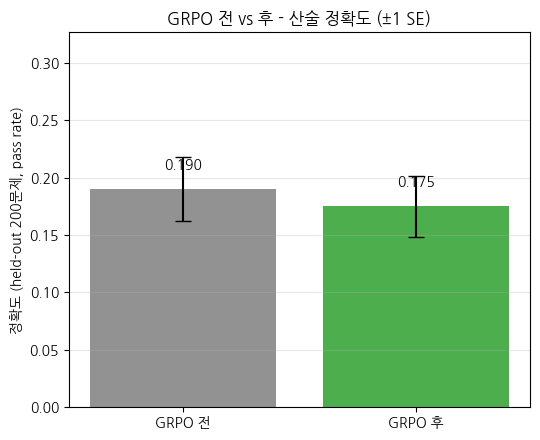

In [11]:
acc_after = eval_accuracy(policy, eval_ds)
n_eval = len(eval_ds)

print(f"AFTER  GRPO - arithmetic accuracy (verifier pass rate): {acc_after:.3f}")
print(f"BEFORE GRPO - arithmetic accuracy                     : {acc_before:.3f}")
print(f"delta                                                 : {acc_after - acc_before:+.3f}")

# 이항 표준오차 - held-out n 문제에서 정확도 p 의 불확실성. |delta| 가 이 안이면 통계적으로 '차이 없음'.
def _se(p, n): return (p * (1 - p) / n) ** 0.5
se_before, se_after = _se(acc_before, n_eval), _se(acc_after, n_eval)
print(f"±1 SE (n={n_eval})                                      : before ±{se_before:.3f}, after ±{se_after:.3f}")
print(f"-> |delta| {abs(acc_after-acc_before):.3f} {'<' if abs(acc_after-acc_before) < max(se_before, se_after) else '>='} 1 SE "
      f"({'오차범위 내: 차이 없음' if abs(acc_after-acc_before) < max(se_before, se_after) else '유의미할 수 있음'})")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
bars = ax.bar(["GRPO 전", "GRPO 후"], [acc_before, acc_after],
              yerr=[se_before, se_after], capsize=6,
              color=["tab:gray", "tab:green"], alpha=0.85)
for b, v in zip(bars, [acc_before, acc_after]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center", va="bottom")
ax.set_ylabel(f"정확도 (held-out {n_eval}문제, pass rate)")
top = max(acc_before + se_before, acc_after + se_after)
ax.set_ylim(0, min(1.0, max(0.3, top * 1.5)))
ax.set_title("GRPO 전 vs 후 - 산술 정확도 (±1 SE)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

**해석 가이드 — verifiable reward 가 *약한 base* 를 못 끌어올리는 경우**

- **before (gray)**: SFT 워밍스타트를 거친 policy 의 held-out 정확도입니다. 2자리 산술은 125M KoGPT2 에 어려워 baseline 이 낮습니다(≈0.19).
- **after (green)**: GRPO 를 수십 step 돌린 뒤에도 정확도가 유의하게 오르지 않습니다 — Δ 가 *±1 SE 안* 이라 통계적으로 *차이 없음(노이즈)* 입니다. 막대의 오차막대가 그걸 보여줍니다.

> **이건 실패가 아니라 GRPO 의 전제조건을 보여주는 정직한 결과입니다.** GRPO 는 *모델이 이미 가끔 성공하는 능력* 을 증폭할 뿐 *없는 능력을 새로 만들지* 못합니다(§7). base 가 2자리 산술을 거의 못 하는 상태(≈0.19)에서는 rollout 대부분이 오답이라 밀어 올릴 *신호* 가 희박합니다.

> 관전 포인트는 *정확도 상승* 이 아니라 **① §6 에서 reward·reward_std 가 살아있는가(=GRPO 가 작동은 하는가), ② 그런데도 held-out 정확도는 왜 안 따라오는가(§7)** 입니다. ⚠️ 더 강한 base(부록의 `Qwen2.5-0.5B-Instruct`)나 format reward 를 쓰면 GRPO 가 *실제로* 정확도를 올립니다 — 부록 `31_grpo_appendix.ipynb` 에서 대비해 보여줍니다.

## 6. 학습 곡선 — GRPO 고유 지표 (reward · KL · clip · 길이 · entropy)

`GRPOTrainer` 는 매 로깅 스텝마다 GRPO 고유 지표를 `trainer.state.log_history` 에 남깁니다. **GRPO 에서는 *loss 값 자체* 를 보는 의미가 거의 없습니다** — supervised loss 처럼 "내려가면 좋은" 양이 아니라, advantage·KL 이 섞인 policy-gradient 목적함수라 부호·크기가 직관적이지 않기 때문입니다(때로 매우 큰 값이 찍히기도 합니다). 대신 아래 지표들을 봅니다:

- **reward / reward_std**: 정책이 *실제로 더 잘 맞히고 있나*. reward 가 오르고, reward_std 가 0 이 아닌(= group 안에 정답·오답이 섞인) 구간에서 학습이 일어납니다.
- **KL(policy‖ref)**: reference(=SFT 모델) 에서 *얼마나 멀어졌나*. `beta=0.04` 앵커가 잘 잡아주면 KL 이 폭주하지 않습니다.
- **clip_ratio**: 업데이트가 *얼마나 잘려나갔나*. 너무 크면 lr/clip 을 재검토하라는 신호입니다.
- **completion 평균 길이 / truncation 비율**: 답이 너무 짧게 끝나는지, `max_completion_length=24` 에 잘려나가는 비율은 얼마인지.
- **entropy**: 생성 분포의 무질서도. 급락하면 *붕괴(collapse)* 조짐입니다.

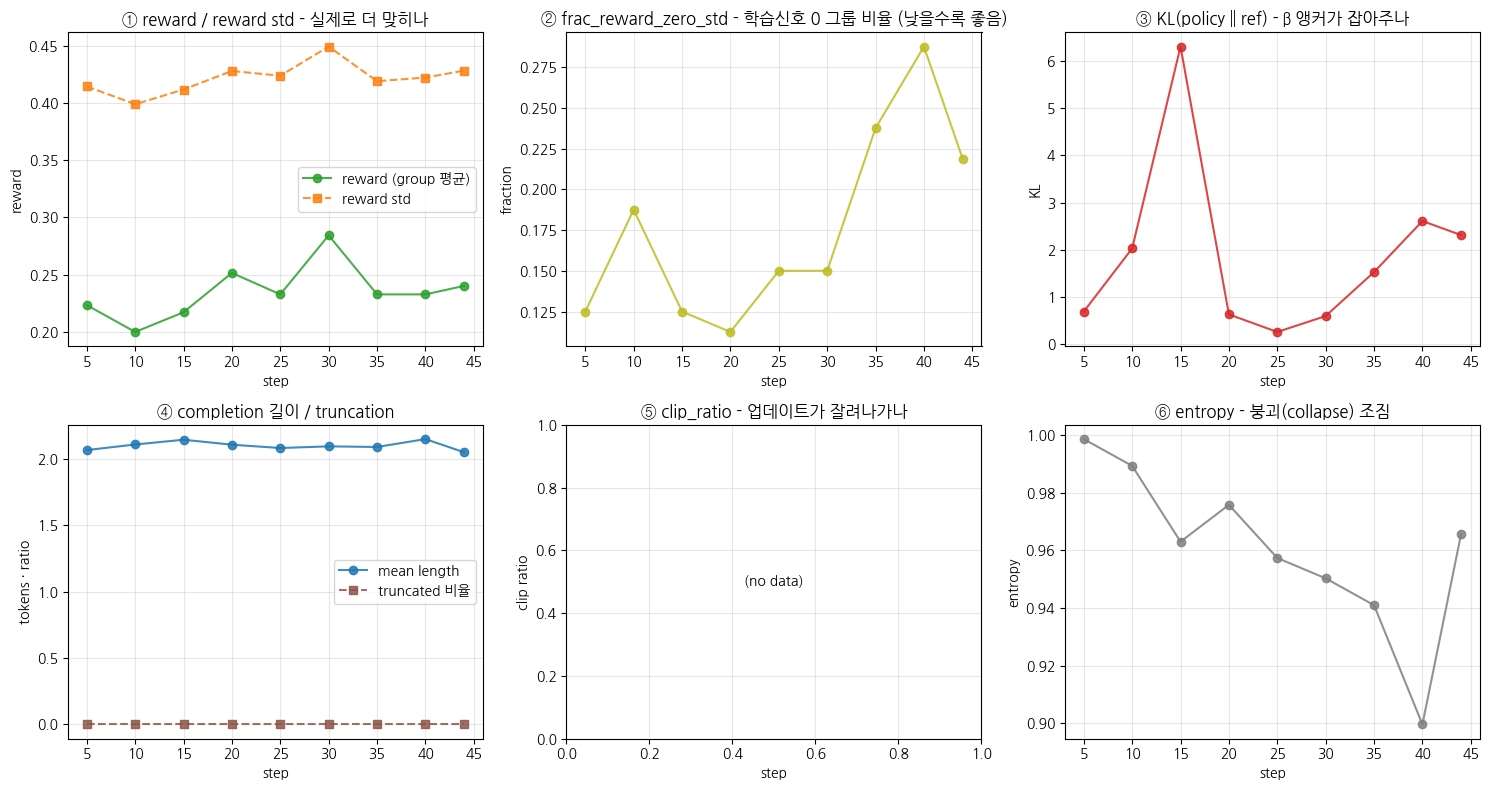

peak VRAM (max over training): 2715 MiB  (policy + reference(β=0.04 KL 앵커), num_generations=8, fp16)


In [12]:
log = trainer.state.log_history


def series(key):
    """log_history 에서 key 가 있는 (step, value) 만 추출 (없는 지표는 빈 리스트)."""
    return [(r["step"], r[key]) for r in log if key in r and r[key] is not None]


# GRPO 고유 지표 - loss 가 아니라 이것들을 봐야 정렬이 되고 있는지 알 수 있다
reward_s     = series("reward")                     # 정책이 실제로 더 맞히나 (group 평균 reward)
reward_std_s = series("reward_std")                 # group 안 다양성
zero_std_s   = series("frac_reward_zero_std")       # group 전체가 같은 reward(=학습신호 0)인 비율 - §4.5 핵심
kl_s         = series("kl")                         # reference(=SFT) 에서 얼마나 멀어졌나
clip_s       = series("clip_ratio")                 # 업데이트가 얼마나 잘려나가나
len_s        = series("completions/mean_length")    # 답 길이 (짧게 끝나나)
trunc_s      = series("completions/clipped_ratio")  # max_completion_length 에 잘린 비율
entropy_s    = series("entropy")                    # 붕괴(collapse) 조짐

fig, axes = plt.subplots(2, 3, figsize=(15, 8))


def _plot(ax, series_list, title, ylabel):
    """series_list: [(data, label, color, marker), ...] 여러 곡선을 한 축에."""
    any_data = False
    for s, label, color, marker in series_list:
        if s:
            any_data = True
            ax.plot([x for x, _ in s], [v for _, v in s], marker, color=color, alpha=0.85, label=label)
    if not any_data:
        ax.text(0.5, 0.5, "(no data)", ha="center", va="center", transform=ax.transAxes)
    ax.set_xlabel("step"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(True, alpha=0.3)
    if any_data and len(series_list) > 1:
        ax.legend()


_plot(axes[0, 0], [(reward_s, "reward (group 평균)", "tab:green", "o-"),
                   (reward_std_s, "reward std", "tab:orange", "s--")],
      "① reward / reward std - 실제로 더 맞히나", "reward")
_plot(axes[0, 1], [(zero_std_s, None, "tab:olive", "o-")],
      "② frac_reward_zero_std - 학습신호 0 그룹 비율 (낮을수록 좋음)", "fraction")
_plot(axes[0, 2], [(kl_s, None, "tab:red", "o-")],
      "③ KL(policy‖ref) - β 앵커가 잡아주나", "KL")
_plot(axes[1, 0], [(len_s, "mean length", "tab:blue", "o-"),
                   (trunc_s, "truncated 비율", "tab:brown", "s--")],
      "④ completion 길이 / truncation", "tokens · ratio")
_plot(axes[1, 1], [(clip_s, None, "tab:purple", "o-")],
      "⑤ clip_ratio - 업데이트가 잘려나가나", "clip ratio")
_plot(axes[1, 2], [(entropy_s, None, "tab:gray", "o-")],
      "⑥ entropy - 붕괴(collapse) 조짐", "entropy")

plt.tight_layout(); plt.show()

if torch.cuda.is_available() and vram_cb.steps:
    print(f"peak VRAM (max over training): {max(vram_cb.peak_MiB):.0f} MiB"
          f"  (policy + reference(β=0.04 KL 앵커), num_generations={GROUP_SIZE}, fp16)")

## 🛠️ 변형 — group size / format reward / 코드 verifier / 다른 task

본 챕터에서 다루지 못한 변형들 — 직접 시도해 보고 싶다면 아래를 출발점으로:

### 변형 1. group size (`num_generations`)

```python
# grpo_config.num_generations = 4   # group 줄이면 rollout 비용 감소, 대신 baseline(group 평균) 추정이 불안정
#                                   # 8 이 본 노트북 기본값. group 안에 정답·오답이 섞이려면 너무 작지 않아야 함 (2 는 비교가 빈약).
```

### 변형 2. format reward 추가 — 여러 verifier 조합

`reward_funcs` 는 *리스트* 로 줄 수 있습니다. 정답 reward + *형식 reward* (예: 정해진 형식으로 답했나) 를 합칠 수 있습니다:

```python
def reward_format(completions, **kwargs):
    '''정답을 '#### 숫자' 형식으로 냈으면 보너스 (형식 준수도 verifiable).'''
    return [0.2 if re.search(r"####\s*-?\d+", c) else 0.0 for c in completions]

# 여러 verifier 를 리스트로 -> reward 가 합산됨 (reward_weights 로 가중치도 가능)
trainer = GRPOTrainer(model=policy, reward_funcs=[reward_correct, reward_format], ...)
```

### 변형 3. 코드 verifier

산술 대신 *코드 생성* task 면, verifier 가 *생성 코드를 실행해 테스트 통과 여부* 를 채점합니다:

```python
def reward_code(completions, test_cases, **kwargs):
    '''생성 코드를 샌드박스에서 실행 -> 테스트 통과하면 1.0 (주의: 샌드박스 필수).'''
    return [1.0 if run_tests_safely(c, t) else 0.0 for c, t in zip(completions, test_cases)]
```

> 코드 실행은 *보안 샌드박스* 가 필수이고 T4 + 30분 룰엔 무거워 본 챕터는 산술로 한정했습니다. 원리는 동일 — *자동 검증 → reward*.

### 변형 4. GSM8K 등 실제 수학 데이터

```python
# from datasets import load_dataset
# gsm = load_dataset("openai/gsm8k", "main", split="train")
# 정답 추출이 더 까다로움 (답이 '#### 42' 형식) -> verifier 의 정답 파싱을 맞춰야 함
```

> 모든 변형의 공통점: *verifier 를 어떻게 정의하나* 가 핵심입니다. *무엇을 reward 로 줄지* = *어떤 능력을 정렬할지*. GRPO 알고리즘 자체는 동일합니다.

## 📦 이번 챕터에 등장한 라이브러리·함수

| 이름 | 한 줄 설명 | Ch 30 과 차이 |
|---|---|---|
| `trl.GRPOTrainer` | GRPO 특화 trainer (rollout → verifier 채점 → group advantage → 정책 갱신 자동) | **새로 등장** (Ch 30 은 `DPOTrainer`) |
| `trl.GRPOConfig` | `GRPOTrainer` 설정 (`TrainingArguments` 상속 + `num_generations`·`max_completion_length`·`beta` 등) | **새로 등장** |
| `reward_funcs` (verifier) | 생성 답을 채점하는 callable (또는 list). `(completions, **kwargs)` → `list[float]` | **새로 등장** (DPO 는 preference 데이터, reward 함수 없음) |
| `GRPOConfig(num_generations=8)` | group size — 한 prompt 당 생성 답 개수 (rollout) | **새로 등장** |
| `GRPOConfig(beta=0.04)` | KL 제약 강도. 작은 값으로 reference(=SFT 모델) 근처에 묶어 collapse·hacking 완화 (0 = ref-free) | **새로 등장** (DPO 의 beta 와 의미 비슷) |
| group relative advantage | `(r - mean) / (std + eps)` — group 평균이 baseline (critic 대체) | **새로 등장** (DPO 는 쌍 비교, advantage 없음) |
| `model.generate(num_return_sequences=k)` | rollout — 한 prompt 에 여러 답 생성 | **새로 등장** (DPO 는 생성 불필요) |
| `PreTrainedTokenizerFast.from_pretrained("skt/kogpt2-base-v2", ...)` | KoGPT2 BBPE (AutoTokenizer 함정 회피) | **공유** (Ch 27 이후 고정) |

> `trl` 은 버전마다 `GRPOTrainer` / `GRPOConfig` API 변동이 큽니다 (`max_prompt_length` 같은 인자가 버전에 따라 없음). 본 노트북은 *버전 간 안정적인 핵심 경로* (`num_generations` + `reward_funcs` + `max_completion_length` + `prompt` 컬럼) 만 사용합니다. 설치된 `trl` 버전은 셋업 셀 출력에서 확인하세요.

## 🎯 체크포인트 질문

1. GRPO 는 *PPO 와 달리 critic (value model) 이 없습니다*. 그런데도 advantage 를 계산할 수 있는 이유는 무엇인가요? (*group 평균* 이라는 단어를 써서 설명)
2. *DPO 와 GRPO* 는 둘 다 alignment (단계 4) 입니다. *신호의 출처* 가 어떻게 다른가요? 각각 *어떤 task* 에 적합한가요?
3. 한 prompt 의 group reward 가 `[1, 1, 1, 1]` (전부 정답) 이면 *advantage 가 전부 0* 이 됩니다. 이게 *왜 학습 신호가 없는* 상태인지, 그리고 *어떻게 다양성을 확보* 하는지 설명해 보세요.
4. *reward hacking* 이란 무엇인가요? verifier 가 *정답 매칭* 일 때 일어날 수 있는 reward hacking 의 예를 하나 들어 보세요.

## ❓ FAQ

### Q1. (이론) GRPO 와 DPO, 언제 무엇을 쓰나요?

*신호의 출처* 가 다르고, 그에 따라 *적합한 task* 가 갈립니다:

| | DPO (Ch 30) | GRPO (Ch 31) |
|---|---|---|
| 신호 | 사람/AI 가 *비교* 한 preference 쌍 | verifier 가 *자동 검증* 한 reward |
| 적합 task | *정답이 없는* 열린 질문 (글쓰기·대화·취향) | *정답을 자동 확인* 가능 (수학·코드·형식) |
| 데이터 비용 | 라벨당 비용 (사람·judge) | 거의 0 (정답만 있으면 무한 rollout) |
| 학습 방식 | 지도학습 (생성 불필요) | RL (rollout - 매 step 생성) |

```python
# 정답이 있는 task -> GRPO
trainer = GRPOTrainer(model, reward_funcs=verifier, ...)   # verifier 가 자동 채점
# 정답이 없는 주관적 품질 -> DPO
trainer = DPOTrainer(model, ref_model=None, ...)           # preference 쌍으로 비교
```

> 실무에서는 *섞어 씁니다* — 검증 가능한 능력(수학·코드)은 GRPO, 주관적 품질(말투·안전성)은 DPO/judge.

### Q2. (실무) verifier 가 없는 task 는 GRPO 를 못 쓰나요?

GRPO 의 전제는 *reward 를 자동으로 매길 수 있어야* 한다는 것입니다. *정답을 자동 판정할 수 없는* task (예: "이 시가 아름다운가") 는 GRPO 의 *깨끗한 신호* 를 얻기 어렵습니다. 대안:

- **LLM-as-judge 를 verifier 로** (Ch 29 부록): 강한 모델이 *점수* 를 매겨 reward 로. 단 judge 의 편향·비용·잡음이 reward 에 섞임 (RLAIF)
- **부분적 verifier**: 형식·길이·금칙어 같은 *검증 가능한 부분만* reward 로 (format reward)
- **DPO 로 전환**: 비교가 더 쉬운 task 면 preference 쌍이 나음

```python
# judge 모델을 reward 로 (예시 - 비용·잡음 주의)
def reward_judge(completions, **kwargs):
    return [judge_model.score(c) for c in completions]   # 0-1 점수
```

> 핵심: *reward 가 신뢰할 만한가* 가 GRPO 성패를 가릅니다. 잡음 많은 reward 는 *잘못된 방향* 으로 정렬합니다.

### Q3. (이론) group size (`num_generations`) 는 결과에 어떤 영향을 주나요?

group 평균이 *baseline (critic 대체)* 이므로, group size 가 *baseline 추정의 안정성* 을 좌우합니다:

- **group 작음** (예: 2): rollout 싸지만, *평균(baseline) 추정이 불안정*. group 안에 *정답·오답이 섞일 확률* 도 낮아져 *advantage 0 (학습 신호 없음)* 인 prompt 가 많아짐
- **group 큼** (예: 8-16): baseline 안정 + 다양성 확보 → advantage 정밀. 단 *rollout 비용 = group size 에 비례* (T4 시간 ↑)

```python
grpo_config.num_generations = 8   # 본 노트북 기본값. 더 작게(4) 하면 rollout 이 가벼워지지만 baseline 추정이 불안정
```

> 직관: group 은 *"이 prompt 에서 동료 몇 명에게 물어볼까"* 입니다. 많을수록 *평균이 믿을 만* 하지만 *물어보는 비용* 이 듭니다.

### Q4. (이론·실무) reward hacking 이란? GRPO 에서 어떻게 막나요?

**reward hacking** = 모델이 *진짜 목표가 아니라 reward 의 허점* 을 찾아 점수만 올리는 현상입니다. verifier 가 *정답 매칭* 일 때의 예:

- verifier 가 *"문자열에 정답 숫자가 들어 있으면 1.0"* 이면, 모델이 *"답은 1 2 3 4 5 6 7 8 9 ..."* 처럼 *모든 숫자를 나열* 해 정답을 포함시킬 수 있음 (풀이 없이 reward 획득)
- *마지막 정수만* 본다면, *엉뚱한 풀이 뒤에 정답만 붙이는* 식으로 우회

막는 법:

```python
# 1) verifier 를 엄격하게 - 정확한 형식 + 정답 둘 다 요구
def reward_strict(completions, answer, **kwargs):
    out = []
    for c, a in zip(completions, answer):
        m = re.search(r"####\s*(-?\d+)\s*$", c.strip())   # 정해진 형식 + 끝에 위치
        out.append(1.0 if (m and m.group(1) == str(a)) else 0.0)
    return out
# 2) beta>0 으로 KL 제약 (reference 에서 멀어지면 페널티 - collapse/hacking 완화)
# 3) format reward 와 정답 reward 를 분리해 reward_weights 로 균형
```

> verifier 설계가 GRPO 의 *가장 중요한 부분* 입니다. *허점 없는 reward* = *원하는 능력* 으로 정렬.

### Q5. (이론) GRPO 가 DeepSeek-R1 의 reasoning 과 무슨 관계인가요?

DeepSeek-R1(-Zero) 은 *수학·코드처럼 정답을 자동 검증* 할 수 있는 문제에 GRPO 를 *대규모로* 적용했습니다. 핵심 발견:

- *사람의 reasoning 데모(SFT) 없이도*, **정답이라는 객관 reward 만으로** 모델이 *스스로 긴 사고 과정(chain-of-thought)* 을 만들어냄
- *"단계를 천천히 밟으면 정답률이 오른다"* 를 모델이 *RL 로 스스로 발견* (생성이 길어지고 self-check 가 나타남)

> Ch 29 부록의 **cons@64** (여러 번 생성해 다수결) 와 같은 뿌리입니다 — *여러 답을 생성해 정답을 골라내는* 평가가, *여러 답을 생성해 정답 방향으로 학습* 하는 GRPO 와 맞물립니다. verifiable task 라서 *생성을 무한히* 할 수 있다는 점이 둘의 공통 전제입니다.

### Q6. (실무) 왜 PPO 대신 GRPO 인가요? (특히 T4)

PPO 는 *actor + critic + reward model + reference* **4 모델** 을 동시에 메모리에 올립니다 — T4 (16GB) 에 무리입니다. GRPO 는:

- **critic 제거** → group 평균이 baseline
- **reward model 제거** → verifier 가 자동 채점 (학습 불필요)
- 남는 건 **policy** (+ 옵션 reference). T4 한 장에서 *rollout 만 감당* 하면 됨

```python
# PPO: actor + critic + reward model + reference (4 모델) -> T4 초과
# GRPO: policy + 작은 KL 앵커(reference=SFT 모델) + verifier(함수) -> T4 가능
GRPOConfig(num_generations=8, beta=0.04, use_vllm=False)   # 작은 KL 앵커 + HF generate
```

> 단 GRPO 도 *rollout (매 step 생성)* 은 PPO 와 공유하므로, *생성 비용* 은 듭니다. T4 에서는 group·step·generation 길이를 작게 잡아 통제합니다.

### Q7. (실무) 작은 모델 (KoGPT2 125M) GRPO 의 한계는?

GRPO 효과는 *출발 모델이 가끔이라도 정답을 내는지* 에 달렸습니다:

- **약한 base + 어려운 task (본 노트북)**: §2.5 SFT 워밍스타트로 출발점을 만들지만, 2자리 산술은 125M 에 어려워 baseline 이 낮습니다(≈0.19). rollout 대부분이 오답이라 밀어 올릴 신호가 희박해, GRPO 를 걸어도 held-out 정확도가 유의하게 오르지 않습니다(§5·§7). *SFT 워밍스타트조차 없이 base 로* 바로 돌리면 group 이 *전부 오답* → std=0 → advantage 0 으로 아예 학습이 안 됩니다
- **작은 모델**: reasoning 능력 자체가 약해 GRPO 로 끌어올릴 *상한* 이 낮음 (R1 은 큰 모델이라 가능)
- **짧은 학습**: 방향을 보기엔 충분하나 극적 변화는 어려움

> 본 챕터의 목표는 *완성된 reasoning 모델* 이 아니라 ***GRPO 가 무엇을 최적화하는가 (verifier reward + group advantage) 를 눈으로 확인*** 하는 것입니다. §3 의 손계산, §6 의 reward·KL 곡선, 그리고 §5·§7 이 말하는 *왜 정확도가 안 따라오는가* 가 핵심. 실전은 *SFT 모델 + 큰 모델 + 많은 rollout + 엄격한 verifier* 의 영역입니다.

## 🔍 왜 reward 가 잘 안 올랐는가 — GRPO 의 전제조건

§5 의 정확도 막대를 보면 GRPO 후 정확도가 SFT 베이스라인에서 **유의하게 오르지 않았습니다**(≈0.19 → ≈0.18, Δ 가 ±1 SE 안이라 통계적으로 *차이 없음*). 이건 *실패가 아니라* GRPO 의 전제조건을 그대로 보여주는 정직한 결과입니다. §2.5 **SFT 워밍스타트**(능력 부여)와 §4.5 **난이도 필터**(group 분산 확보) 덕분에 GRPO 가 *작동은* 했지만(§6 에서 reward_std>0 로 확인), 2자리 산술이 125M KoGPT2 에 너무 어려워 *정확도까지 끌어올리진* 못했습니다. 만약 이 두 전제조건조차 없이 base 로 바로 GRPO 를 돌렸다면 group reward 가 전부 0/전부 1 로 쏠려 학습 신호 자체가 사라졌을 겁니다. 이번 절에서 그 이유 — *GRPO 는 없는 능력을 새로 만들지 못한다* — 를 짚습니다.

### 증상 — group reward 가 대부분 0

2자리 산술은 125M KoGPT2 에 어렵습니다. 한 prompt 에 답을 여러 개 생성하면 *대부분 전부 오답* → group reward 가 `[0, 0, 0, 0]` 이 되기 쉽습니다. §3 의 손계산에서 봤듯이 (std 는 표본표준편차 ddof=1):

| group reward | mean | std | advantage | 학습 신호 |
|---|---|---|---|---|
| `[0, 0, 0, 0]` (전부 오답) | 0 | 0 | **전부 0** | **없음** |
| `[1, 1, 1, 1]` (전부 정답) | 1 | 0 | **전부 0** | **없음** |
| `[1, 0, 1, 0]` (섞임) | 0.5 | 0.58 | `[+0.87,-0.87,+0.87,-0.87]` | **있음** |

SFT 워밍스타트 *없이* base 로 바로 GRPO 를 돌리면 거의 매번 첫 번째 줄(`[0,0,0,0]`)에 빠집니다 — 그래서 §2.5 에서 SFT 를 먼저 했습니다. 그럼에도 base 정확도가 낮아(≈0.19) 난이도 필터를 통과한 prompt 조차 group 이 자주 한쪽으로 쏠려, GRPO 가 *정확도를 끌어올릴* 만큼의 일관된 신호를 얻지 못합니다.

### 근본 원인 — GRPO 는 "무에서 유" 를 만들지 못한다

GRPO 의 advantage 는 $A_i = (r_i - \text{mean}) / (\text{std} + \varepsilon)$ 입니다. group 안의 *모든 답이 같은 reward* 면 std = 0 → **advantage 0 → gradient 0 → 학습 신호 없음**. 즉 GRPO 가 작동하려면 *group 안에 잘한 답과 못한 답이 섞여 있어야* 합니다. 그런데 모델이 task 를 *아예 못 풀면* 모든 답이 똑같이 reward 0 이라 비교 자체가 불가능합니다.

> **핵심 교훈**: GRPO(RL)는 SFT 처럼 *없던 능력을 새로 가르치지* 못합니다. *모델이 이미 가끔이라도 성공하는 능력* 을 그 방향으로 **증폭** 하는 기법입니다. 그래서 *"가끔이라도 정답이 나와야"* GRPO 가 그 방향을 강화할 수 있습니다. base KoGPT2 처럼 *한 번도 성공하지 못하는* 모델에는 증폭할 신호 자체가 없습니다.

작은 base 모델 (KoGPT2 125M) + 어려운 task (산술) = **reward 가 sparse(희소)** = GRPO 가 *출발점* 을 잡지 못하는 전형적 상황입니다. DeepSeek-R1 이 *순수 RL* 로 reasoning 을 끌어낼 수 있었던 것도 *충분히 큰 base 모델* 에서 출발했기 때문입니다 — 큰 모델은 어려운 문제도 *가끔* 맞히므로 group 에 다양성이 생기고, GRPO 가 그 *가끔의 성공* 을 증폭할 수 있었습니다.

### reward 가 안 오를 때의 해결 레버 4가지

| 레버 | 무엇을 | 왜 도움이 되나 |
|---|---|---|
| **(1) SFT 먼저** | instruction-response 로 형식·기초를 먼저 가르침 (Ch 28) | base 가 *가끔이라도 정답·형식* 을 내게 만들어 group 다양성 확보 |
| **(2) 더 강한 base 모델** | KoGPT2 125M → 산술 가능한 더 큰/능력 있는 모델 | 어려운 문제도 *가끔 맞혀* group reward 에 차이 발생 |
| **(3) task 난이도 ↓** | 더 쉬운 문제부터 (한 자리 덧셈 등) | 성공 확률 ↑ → group 에 정답이 섞일 확률 ↑ |
| **(4) format reward + HPO** | 정답 형식을 따르면 *부분 보상* + group size↑·temperature↑ | reward 가 *0 만 나오는 것* 을 막아 *학습 신호를 확보*. 형식 준수만으로도 std>0 |

특히 **(4) format reward** 는 작은 모델에 강력합니다. 정답을 *못 맞혀도* 답을 *정해진 형식* (예: `"정답: N"`) 으로 내면 0.2 같은 부분 보상을 줍니다. 그러면 group 안에서 *형식을 지킨 답 vs 안 지킨 답* 의 reward 차이가 생겨 (예: `[0.2, 0.0, 0.2, 0.0]`) std>0 → **advantage 가 0 에서 벗어나 학습이 시작** 됩니다. 모델이 먼저 *형식* 을 배우고, 그 위에서 *정답* 으로 나아가는 사다리를 놓는 셈입니다.

### → 부록에서 reward 가 실제로 오르는 모습 확인

이 챕터의 GRPO 여정과 그 도착점은 **두 부록** 에서 더 깊이 봅니다:

- **디버깅 여정** — [`31_grpo_appendix.ipynb`](./31_grpo_appendix.ipynb): base 로 바로 GRPO(실패) → SFT 워밍스타트 → 난이도 필터로 신호를 되살리는 *실제 과정* 을 단계별로 재현합니다(본 챕터와 같은 설정·seed).
- **reward 를 *실제로* 올리는 GRPO** — [`appendix_qwen_grpo_hpo.ipynb`](./appendix_qwen_grpo_hpo.ipynb): **(2) 더 강한 base**(`Qwen/Qwen2.5-0.5B-Instruct`, 산술을 *가끔 맞히는* 모델) + **(4) format reward**(correctness + format 조합으로 *0 만 나오는 것* 방지) + **HPO**(`num_generations`·`temperature`·`beta`·`learning_rate` 가 reward·수렴에 주는 영향)를 적용해, *본 챕터의 KoGPT2 와 대비* 되도록 **reward 가 실제로 오르는** 셋업을 시연합니다.

본문은 *GRPO 의 전제조건을 (정확도가 안 오르는 현상으로) 체감* 하는 챕터, 부록은 *그 전제조건을 충족시켜 reward 를 올리는* 챕터입니다.

> 한 문장 요약: ***GRPO 는 모델이 이미 가끔 성공하는 능력을 증폭할 뿐, 무에서 유를 만들지 못한다. 그래서 RL 전에 SFT·충분한 base·format reward 로 "출발점" 을 먼저 마련해야 한다.***

## 🎓 Phase 4 회고 + Phase 5 예고

### Phase 4 완성 — encoder 에서 decoder 로, pretraining 에서 alignment 로

Ch 24-31 의 **Phase 4 (GPT 시대)** 를 마칩니다. Phase 1-3 이 *encoder (BERT)* 로 *이해(분류)* 를 다뤘다면, Phase 4 는 *decoder (GPT)* 로 *생성* 과 *학습 4단계 전체* 를 통과했습니다:

| 단계 | 챕터 | 무엇을 | 학습 신호 |
|---|---|---|---|
| 1 **Pretraining** | Ch 24 (영어), Ch 26 (한국어) | scratch GPT 를 일반 코퍼스로 | next-token |
| 2 **Continual pretraining** | Ch 25 (영어), Ch 27 (한국어) | 사전학습 모델에 새 데이터 | next-token |
| 3 **SFT** | Ch 28 | 지시를 따르게 (행동 정렬) | response 토큰 |
| 4 **Alignment** (DPO) | Ch 30 | 사람 선호로 (주관적 비교) | preference 쌍 |
| 4 **Alignment** (GRPO) | **Ch 31 ← 여기** | 정답으로 (객관적 검증) | verifier reward + group advantage |

**Phase 4 를 관통한 thread**:
- **`labels = -100` 의 response-only**: SFT(답변만 학습) → DPO(답변만 비교) 로 이어짐
- **영/한 대칭**: pretraining·continual pretraining 을 영어(Ch 24·25)와 한국어(Ch 26·27) 로 대칭 진행
- **alignment 의 두 방식**: DPO(주관적 선호) 와 GRPO(객관적 정답) — *신호의 출처* 가 정렬 방법을 나눔
- **PPO 의 두 갈래 간소화**: DPO(reward model + RL 루프 제거), GRPO(critic + reward model 제거) — 둘 다 *T4 에서 alignment 를 손으로* 돌려볼 수 있게 함

### Phase 5 예고 — Diffusion LM (Ch 32-34), 새 패러다임

Phase 1-4 의 모든 모델은 *autoregressive* 였습니다 — *왼쪽에서 오른쪽으로, 한 토큰씩* 생성 (MLM 도 결국 토큰 단위 예측). **Phase 5 는 완전히 다른 생성 패러다임 — Diffusion Language Model** 을 다룹니다:

- **autoregressive (지금까지)**: 토큰을 *순차적* 으로 하나씩. 이전 토큰이 다음 토큰의 조건
- **diffusion (Phase 5)**: *전체 시퀀스를 한꺼번에* 두고, *잡음(masked/noised) 상태에서 병렬로 denoise* 해 점진적으로 완성. 이미지 diffusion (노이즈에서 그림으로) 의 텍스트 버전

> Phase 5 (Ch 32-34) 에서는 *왜 텍스트에 diffusion 을 적용하는가*, *autoregressive 대비 무엇이 다른가* (병렬 생성·양방향 문맥·되돌리기), 그리고 *작은 diffusion LM 을 직접 학습* 해 봅니다. *한 토큰씩* 이라는 Phase 1-4 의 대전제를 깨는, 커리큘럼의 새 막입니다.

**다음 챕터: Chapter 32 — Diffusion Language Model 입문 (autoregressive 가 아닌 병렬 denoise).**